**EDA(Exploratory Data Analytics)**

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df=pd.read_csv("tips.csv")

In [3]:
df.head()

,total_bill,tip,gender,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [6]:
df.tail()

,total_bill,tip,gender,smoker,day,time,size
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2
243,18.78,3.00,Female,No,Thur,Dinner,2


In [7]:
df.describe

<bound method NDFrame.describe of      total_bill   tip  gender smoker   day    time  size
0         16.99  1.01  Female     No   Sun  Dinner     2
1         10.34  1.66    Male     No   Sun  Dinner     3
2         21.01  3.50    Male     No   Sun  Dinner     3
3         23.68  3.31    Male     No   Sun  Dinner     2
4         24.59  3.61  Female     No   Sun  Dinner     4
..          ...   ...     ...    ...   ...     ...   ...
239       29.03  5.92    Male     No   Sat  Dinner     3
240       27.18  2.00  Female    Yes   Sat  Dinner     2
241       22.67  2.00    Male    Yes   Sat  Dinner     2
242       17.82  1.75    Male     No   Sat  Dinner     2
243       18.78  3.00  Female     No  Thur  Dinner     2

[244 rows x 7 columns]>

In [8]:
df.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   total_bill  244 non-null    float64
 1   tip         244 non-null    float64
 2   gender      244 non-null    object 
 3   smoker      244 non-null    object 
 4   day         244 non-null    object 
 5   time        244 non-null    object 
 6   size        244 non-null    int64  
dtypes: float64(2), int64(1), object(4)
memory usage: 13.5+ KB


In [10]:
df.shape


(244, 7)

In [11]:
df['day'].value_counts()

day
Sat     87
Sun     76
Thur    62
Fri     19
Name: count, dtype: int64

In [12]:
df['day'].value_counts(normalize=True)#percentages

day
Sat     0.356557
Sun     0.311475
Thur    0.254098
Fri     0.077869
Name: proportion, dtype: float64

In [ ]:
df.groupby("gender")["total_bill"]

gender
Female     87
Male      157
Name: total_bill, dtype: int64

<BarContainer object of 4 artists>

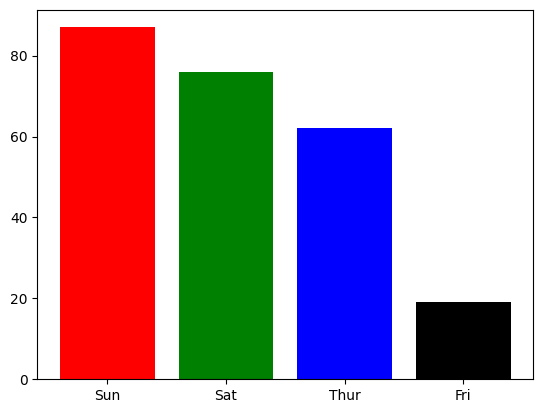

In [20]:
plt.bar(df['day'].unique(),df['day'].value_counts(),color=["red","green",'blue',"black"])

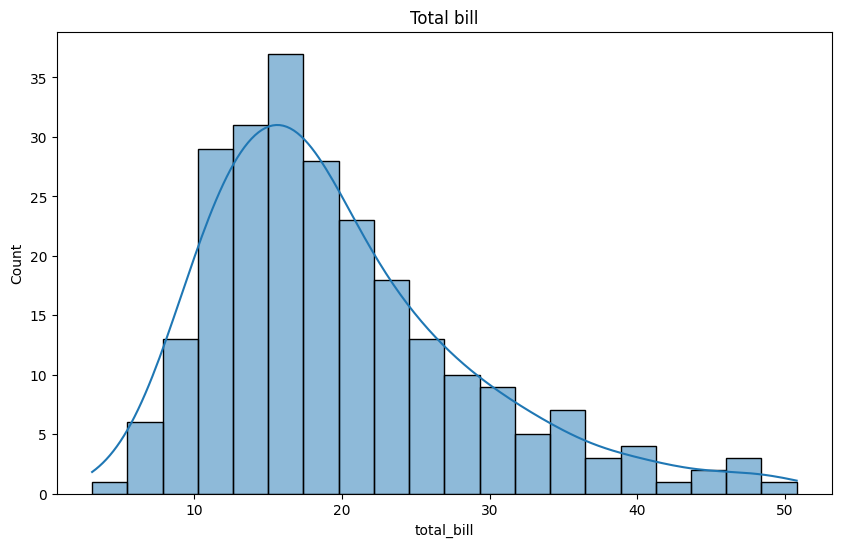

In [22]:
plt.figure(figsize=(10,6))
sns.histplot(df['total_bill'],kde=True,bins=20)#In Seaborn (sns), kde stands for Kernel Density Estimate.
# A Kernel Density Estimate (KDE) is a way to estimate the probability density function (PDF) of a continuous variable. 
# Instead of showing raw counts (like a histogram),
#  KDE smooths the distribution into a continuous curve, making it easier to see the underlying shape of the data.
# How it works
plt.title("Total bill")
plt.show()

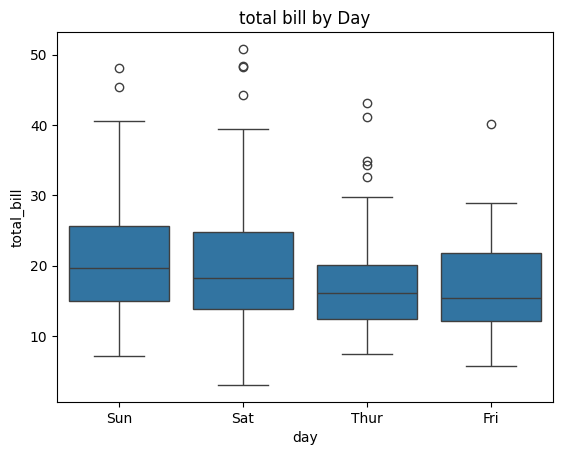

In [23]:
sns.boxplot(x='day',y='total_bill',data=df)
plt.title("total bill by Day")
plt.show()

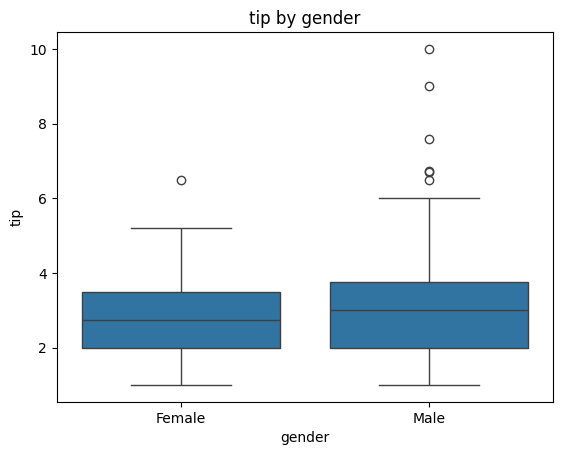

In [31]:
sns.boxplot(x='gender',y='tip',data=df)
plt.title('tip by gender')
plt.show()

In [28]:
df.groupby('gender')['tip'].sum()


gender
Female    246.51
Male      485.07
Name: tip, dtype: float64

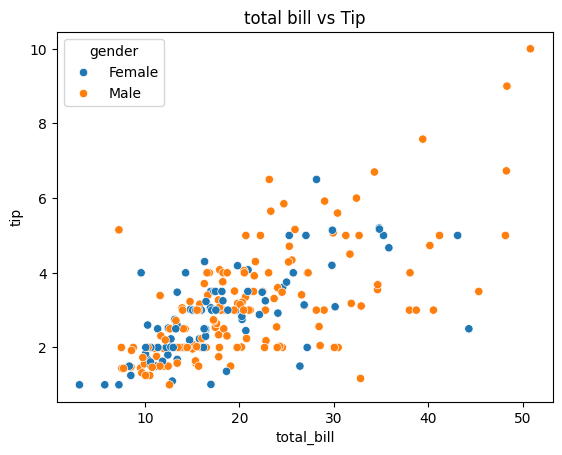

In [29]:
#scatter plot
sns.scatterplot(x='total_bill',y='tip',hue='gender',data=df)
plt.title("total bill vs Tip")
plt.show()

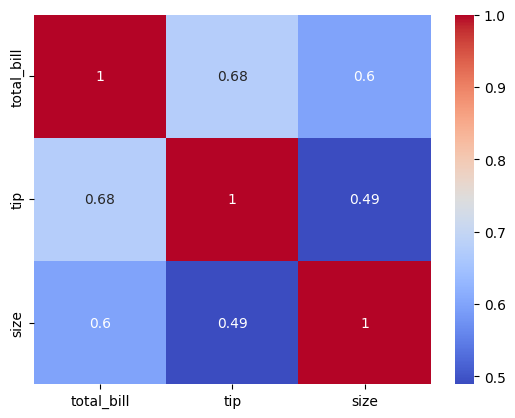

In [32]:
#coorelation matrix
corr_mat=df.select_dtypes(include="number").corr()
sns.heatmap(corr_mat,annot=True,cmap='coolwarm')
plt.show()

In [39]:
from scipy import stats
#Relationship between gender and smoker
contingency_table=pd.crosstab(df['gender'],df['smoker'])
print(contingency_table)
chi2,p,dof,expected=stats.chi2_contingency(contingency_table,correction=False)
print(f"chi2 : {chi2} , p-value:{p}")
print(f"expected value : {expected}")

smoker  No  Yes
gender         
Female  54   33
Male    97   60
chi2 : 0.001934818536627623 , p-value:0.964915107315732
expected value : [[53.84016393 33.15983607]
 [97.15983607 59.84016393]]


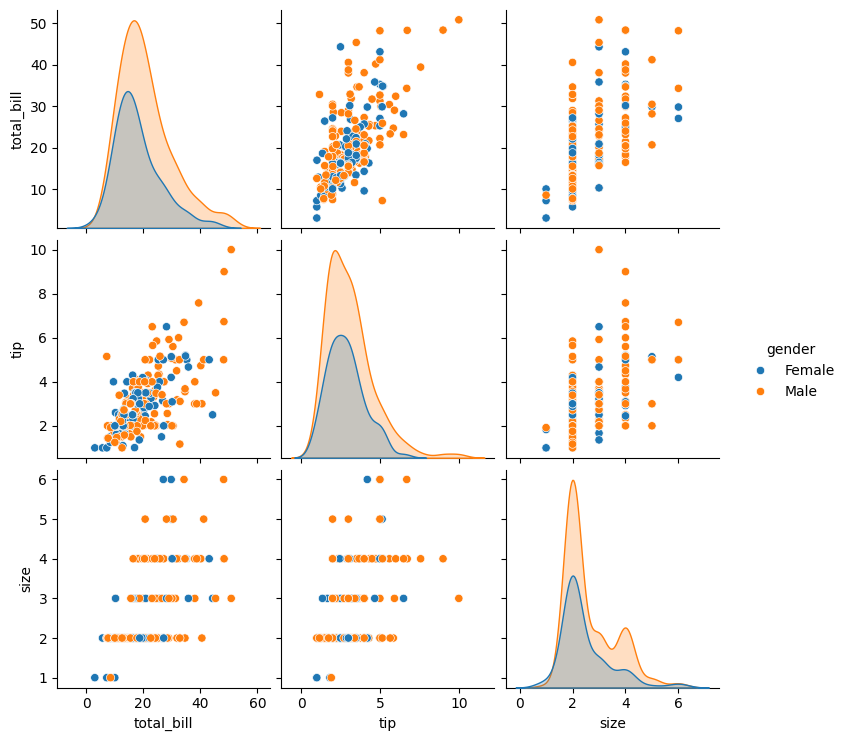

In [40]:
sns.pairplot(df,hue='gender')
plt.show()

**Automation of EDA Workflows**

In [41]:
df.dtypes

total_bill    float64
tip           float64
gender         object
smoker         object
day            object
time           object
size            int64
dtype: object

In [42]:
df.memory_usage(deep=True).sum()

np.int64(57733)

In [45]:
df.select_dtypes(include='object').head()

,gender,smoker,day,time
0,Female,No,Sun,Dinner
1,Male,No,Sun,Dinner
2,Male,No,Sun,Dinner
3,Male,No,Sun,Dinner
4,Female,No,Sun,Dinner
